# Northwind Utilities | data analysis behind the project


| `DataTag` | File | What it holds |
|---|---|---|
| **A** | `northwind_complaints.csv` | 25,416 individual complaints, Oct 2024 – Sep 2026 |
| **B** | `northwind_systems.csv` | The 15 IT systems (age, stack, integration, run cost) |
| **C** | `northwind_monthly_kpis.csv` | 24 months of operational KPIs |
| **D** | `northwind_meter_reads.csv` | Monthly meter-read quality per region |
| **E** | `northwind_ai_pilot_2025.csv` | AskNorthwind AI assistant pilot, Jan – Sep 2025 |
| **F** | `northwind_unit_costs.csv` | Finance unit-cost model FY26 |
| **G** | `northwind_contact_centre_staffing.csv` | Contact-centre staffing per region per month |

**Where each number is used in the project**

| Section | Project location | Claims reproduced |
|---|---|---|
| 1 | Landing page (`App.tsx`), Problem slide source line | 1.8 M customers · 25,416 complaints · Oct 2024 – Sep 2026 |
| 2 | Problem slide + `ProblemCharts.tsx` | 38 days to close · 4× longer · 35 % transferred (8,870 / 16,546) · reopen 29 % vs 9 % (3×) · 51 % billing + category bars |
| 3 | Data Findings slide | 1,718 missed appointments, 71 % breach SLA · 1998 COBOL billing · 10 % AI containment, CSAT 2.0 · Calderfield 41 % attrition, 32 vacancies, 5.5 complaints/agent |
| 4 | Impact slide | ~$235K/yr transfer cost (4,435 × $53) · 23 % information-only · 77 % SLA breached |
| 5 | Manager staffing dashboard (`StaffingDashboard.tsx`) | FTE-weighted attrition & complaints per agent, month-over-month deltas |
| 6 | Supporting analysis | KPI trends, backlog, channels/regions/priority, meter reads, systems, unit costs |
| 7 | Verification table | Every claim, computed value vs. value shown in the project |

Every claim is registered with `claim(...)` as it is computed; section 7 prints the full audit table.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# Works whether the notebook is run from the repo root or from analysis/
DATA = next(p for p in (Path("csv"), Path("../csv")) if (p / "northwind_complaints.csv").exists())

complaints = pd.read_csv(DATA / "northwind_complaints.csv", parse_dates=["date_opened", "date_closed"])
systems    = pd.read_csv(DATA / "northwind_systems.csv")
kpis       = pd.read_csv(DATA / "northwind_monthly_kpis.csv")
meters     = pd.read_csv(DATA / "northwind_meter_reads.csv")
ai_pilot   = pd.read_csv(DATA / "northwind_ai_pilot_2025.csv")
unit_costs = pd.read_csv(DATA / "northwind_unit_costs.csv")
staffing   = pd.read_csv(DATA / "northwind_contact_centre_staffing.csv")

TABLES = {
    "A complaints": complaints, "B systems": systems, "C monthly_kpis": kpis, "D meter_reads": meters,
    "E ai_pilot_2025": ai_pilot, "F unit_costs": unit_costs, "G staffing": staffing,
}

In [4]:
# ---- Chart style (validated reference palette; thin marks, recessive grid, one axis per chart) ----
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948")
CATEGORICAL = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
EMPHASIS, DEEMPH = BLUE, "#c3c2b7"
CRITICAL = "#d03b3b"  # status colour: only for SLA breach

REGIONS = sorted(meters.region.unique())
REGION_COLOR = dict(zip(REGIONS, CATEGORICAL))  # colour follows the region everywhere

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.family": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 10,
    "lines.linewidth": 2, "lines.markersize": 5, "legend.frameon": False, "axes.axisbelow": True,
})

def pct_axis(ax, axis="y", decimals=0):
    fmt = mtick.PercentFormatter(1.0, decimals=decimals)
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

def hbar(ax, labels, values, emphasis=None, fmt="{:,.0f}", color=None):
    # Horizontal bars, largest first, with a value label at each bar end
    colors = [color or (EMPHASIS if emphasis is None or emphasis(l) else DEEMPH) for l in labels]
    bars = ax.barh(labels, values, color=colors, height=0.66, edgecolor=SURFACE, linewidth=2)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
    ax.tick_params(axis="y", colors=INK_2, length=0)
    for b, v in zip(bars, values):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2, "  " + fmt.format(v), va="center", color=INK_2, fontsize=9)
    ax.set_xlim(0, max(values) * 1.18)
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    return bars

def month_ticks(ax, months, every=3):
    ax.set_xticks(range(0, len(months), every))
    ax.set_xticklabels([pd.Period(m).strftime("%b\n%Y") for m in months[::every]])

In [5]:
# ---- Claim registry: every number shown in the project is checked against the data ----
CLAIMS = []

def claim(where, statement, computed, shown, ok=None, note=""):
    # `shown` is the value displayed in the project; `ok` defaults to "rounds to the same thing"
    if ok is None:
        ok = True
    CLAIMS.append({"where": where, "statement": statement, "computed": computed, "shown in project": shown,
                   "verified": "✅" if ok else "⚠️", "note": note})
    return computed

def rounds_to(x, shown, places=0):
    return round(x, places) == shown

## 0. Data inventory & quality checks
Shape, columns and missing values for all seven files, then consistency checks between files.

In [6]:
inventory = pd.DataFrame([
    {"table": name, "rows": len(df), "columns": df.shape[1], "missing cells": int(df.isna().sum().sum()),
     "column names": ", ".join(df.columns)}
    for name, df in TABLES.items()
])
display(inventory)

,table,rows,columns,missing cells,column names
0,A complaints,25416,18,23938,"complaint_id, date_opened, date_closed, status..."
1,B systems,15,11,0,"system_id, system_name, purpose, year_installe..."
2,C monthly_kpis,24,8,0,"month, complaints_opened, complaints_closed, a..."
3,D meter_reads,144,7,0,"month, region, accounts, estimated_read_rate, ..."
4,E ai_pilot_2025,9,8,0,"month, assistant_sessions, fully_contained_rat..."
5,F unit_costs,10,4,0,"item, unit_cost, unit, source_note"
6,G staffing,144,7,135,"month, region, agent_fte, open_vacancies, attr..."


In [7]:
display(Markdown("**Complaints — missing values by column (only non-zero shown)**"))
missing = complaints.isna().sum()
display(missing[missing > 0].to_frame("missing"))

open_mask = complaints.status.eq("Open")
print("Open complaints:", open_mask.sum())
print("Every missing date_closed / days_to_close / resolution belongs to an Open complaint:",
      complaints.loc[complaints.date_closed.isna(), "status"].eq("Open").all())
print("bill_correction_value is only filled for billing/metering corrections:",
      complaints.dropna(subset=["bill_correction_value"]).category.unique().tolist())

closed = complaints[~open_mask].copy()
print("days_to_close == date_closed - date_opened for every closed complaint:",
      ((closed.date_closed - closed.date_opened).dt.days == closed.days_to_close).all())
print("sla_days maps 1:1 to priority:", complaints.groupby("priority").sla_days.unique().to_dict())
print("Unique accounts:", complaints.account_id.nunique(), "| accounts with >1 complaint:",
      (complaints.account_id.value_counts() > 1).sum())

**Complaints — missing values by column (only non-zero shown)**

,missing
date_closed,1599
days_to_close,1599
resolution_action,1599
resolvable_by_information_only,1599
bill_correction_value,17542


Open complaints: 1599
Every missing date_closed / days_to_close / resolution belongs to an Open complaint: True
bill_correction_value is only filled for billing/metering corrections: ['Billing - disputed amount', 'Billing - estimated read', 'Metering - no read taken']
days_to_close == date_closed - date_opened for every closed complaint: True
sla_days maps 1:1 to priority: {'P1': array([5], dtype=int64), 'P2': array([10], dtype=int64), 'P3': array([20], dtype=int64)}
Unique accounts: 25074 | accounts with >1 complaint: 337


### Reconciliation: complaint rows ↔ monthly KPI file
The KPI file (C) is a roll-up of the complaint file (A): *opened* counts group by the month opened, while
*closed* counts and *avg days to close* group by the month **closed**. Both reconcile exactly, so the two
files can be used interchangeably.

In [8]:
complaints["open_month"] = complaints.date_opened.dt.strftime("%Y-%m")
complaints["close_month"] = complaints.date_closed.dt.strftime("%Y-%m")

by_close = complaints.dropna(subset=["date_closed"]).groupby("close_month")
recon = pd.DataFrame({
    "opened (A)": complaints.groupby("open_month").size(),
    "opened (C)": kpis.set_index("month").complaints_opened,
    "closed (A)": by_close.size(),
    "closed (C)": kpis.set_index("month").complaints_closed,
    "avg days (A)": by_close.days_to_close.mean().round(1),
    "avg days (C)": kpis.set_index("month").avg_days_to_close,
})
display(recon)
print("Opened match:", (recon["opened (A)"] == recon["opened (C)"]).all(),
      "| Closed match:", (recon["closed (A)"] == recon["closed (C)"]).all(),
      "| Avg days match:", np.allclose(recon["avg days (A)"], recon["avg days (C)"]))

,opened (A),opened (C),closed (A),closed (C),avg days (A),avg days (C)
2024-10,912,912,476,476,9.1,9.1
2024-11,830,830,760,760,16.5,16.5
2024-12,951,951,873,873,18.4,18.4
2025-01,985,985,927,927,19.5,19.5
2025-02,851,851,840,840,20.1,20.1
2025-03,901,901,901,901,21.4,21.4
2025-04,1023,1023,952,952,22.0,22.0
2025-05,1004,1004,942,942,23.2,23.2
2025-06,982,982,965,965,23.1,23.1
2025-07,1222,1222,1062,1062,24.9,24.9


Opened match: True | Closed match: True | Avg days match: True


## 1. Headline scale — landing page & Problem-slide source line
*“Northwind Utilities is a regulated energy and water provider serving **1.8 million customers**”* (landing page)
and *“**25,416 complaints, Oct 2024 – Sep 2026**”* (Problem slide footer).

In [9]:
accounts_per_month = meters.groupby("month").accounts.sum()
total_accounts = int(accounts_per_month.iloc[-1])
print("Accounts per month (constant across all months):", accounts_per_month.unique())
display(meters[meters.month == meters.month.max()][["region", "accounts"]].set_index("region").T)

n_complaints = len(complaints)
first, last = complaints.date_opened.min(), complaints.date_opened.max()
print(f"Total accounts: {total_accounts:,} | Complaints: {n_complaints:,} | Opened {first:%d %b %Y} – {last:%d %b %Y}")
print(f"Complaint rate: {n_complaints / total_accounts * 1000:.1f} complaints per 1,000 accounts over 2 years")

claim("Landing page / Problem slide", "Customers served", f"{total_accounts / 1e6:.1f}M", "1.8M", total_accounts == 1_800_000)
claim("Problem slide footer", "Complaints in the data set", f"{n_complaints:,}", "25,416", n_complaints == 25416)
claim("Problem slide footer", "Date range", f"{first:%b %Y} – {last:%b %Y}", "Oct 2024 – Sep 2026",
      (first.strftime("%Y-%m"), last.strftime("%Y-%m")) == ("2024-10", "2026-09"));

Accounts per month (constant across all months): [1800000]


region,Ashford,Barrowdale,Calderfield,Dunmoor,Eastmarch,Fenwick
accounts,412000,298000,355000,221000,304000,210000


Total accounts: 1,800,000 | Complaints: 25,416 | Opened 01 Oct 2024 – 30 Sep 2026
Complaint rate: 14.1 complaints per 1,000 accounts over 2 years


## 2. The Problem slide
### 2.1 “A complaint now takes 38 days to close” — “4× longer than two years ago”
Source: `avg_days_to_close` in the KPI file (C), identical to complaints grouped by close month (A).
This is the data behind `DaysToCloseChart` in `ProblemCharts.tsx`.

2024-10: 9.1 days → 2026-09: 38.2 days  = 4.20× longer
Linear trend: +1.04 days per month


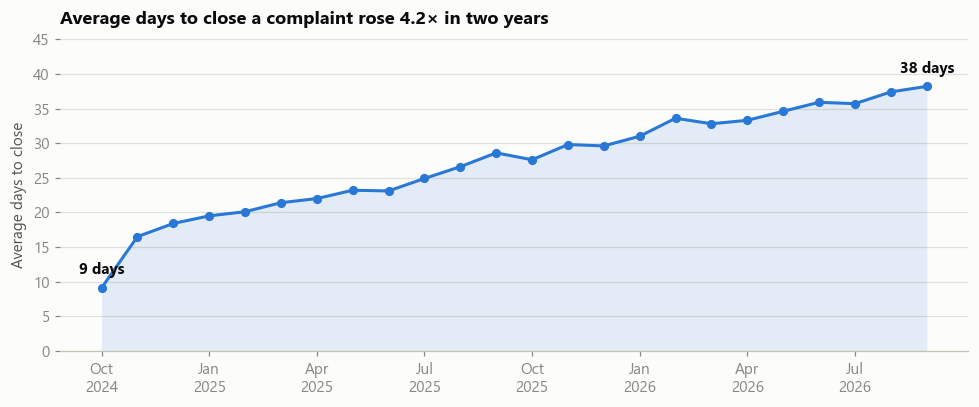

In [10]:
d0, d1 = kpis.avg_days_to_close.iloc[0], kpis.avg_days_to_close.iloc[-1]
ratio = d1 / d0
slope = np.polyfit(np.arange(len(kpis)), kpis.avg_days_to_close, 1)[0]
print(f"{kpis.month.iloc[0]}: {d0} days → {kpis.month.iloc[-1]}: {d1} days  = {ratio:.2f}× longer")
print(f"Linear trend: +{slope:.2f} days per month")

claim("Problem slide title", "Avg days to close, Sep 2026", f"{d1} days", "38 days", round(d1) == 38)
claim("Problem slide", "Days to close vs Oct 2024", f"{ratio:.2f}×", "4×", round(ratio) == 4)
claim("ProblemCharts DaysToCloseChart", "Chart start / end labels", f"{d0:.0f} → {d1:.0f} days", "9 days → 38 days",
      (round(d0), round(d1)) == (9, 38))

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(kpis))
ax.fill_between(x, kpis.avg_days_to_close, color=BLUE, alpha=0.12, linewidth=0)
ax.plot(x, kpis.avg_days_to_close, color=BLUE, marker="o")
for i in (0, len(kpis) - 1):
    ax.annotate(f"{kpis.avg_days_to_close[i]:.0f} days", (i, kpis.avg_days_to_close[i]), textcoords="offset points",
                xytext=(0, 9), ha="center", color=INK, fontweight="bold")
month_ticks(ax, kpis.month.tolist())
ax.set_ylim(0, 45); ax.set_ylabel("Average days to close")
ax.set_title(f"Average days to close a complaint rose {ratio:.1f}× in two years")
plt.tight_layout(); plt.show()

> **Caveat worth knowing for Q&A.** Oct 2024 is the first month of the data set, so only complaints opened *that
> month* could close in it — fast ones — which pulls 9.1 days down. Starting from Nov 2024 (16.5 days) the rise is
> still **2.3×**. Grouping by the month a complaint was **opened** tells the same story until the most recent
> months, which are right-censored (most are still open or closed only if fast):

In [11]:
cohort = complaints.groupby("open_month").agg(opened=("complaint_id", "size"),
                                              still_open=("status", lambda s: (s == "Open").sum()),
                                              avg_days_closed_only=("days_to_close", "mean")).round(1)
display(cohort.T)
print(f"Nov 2024 → Sep 2026 (close-month basis): {d1 / kpis.avg_days_to_close.iloc[1]:.2f}×")

open_month,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
opened,912.0,830.0,951.0,985.0,851.0,901.0,1023.0,1004.0,982.0,1222.0,1026.0,1020.0,1189.0,940.0,1120.0,1177.0,1002.0,1171.0,1190.0,1049.0,1164.0,1271.0,1185.0,1251.0
still_open,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,78.0,409.0,1101.0
avg_days_closed_only,17.6,19.4,19.5,20.5,21.7,21.8,23.6,24.2,24.9,26.8,28.5,27.8,29.6,31.1,31.9,32.9,33.3,34.6,34.6,36.5,36.4,34.9,27.5,13.9


Nov 2024 → Sep 2026 (close-month basis): 2.32×


### 2.2 “35 % of complaints bounce between systems; those reopen 3× as often”
Source: `transferred_between_systems` and `reopened` in the complaint file (A). Data behind `TransferChart`.

,complaints,share of all,closed,reopened,reopen rate (of closed)
transferred_between_systems,,,,,
Handled in one system,16546,65.1%,15668,1394,8.9%
Transferred between systems,8870,34.9%,8149,2382,29.2%


Reopen ratio: 3.29×  (all-complaints basis: 3.19×)


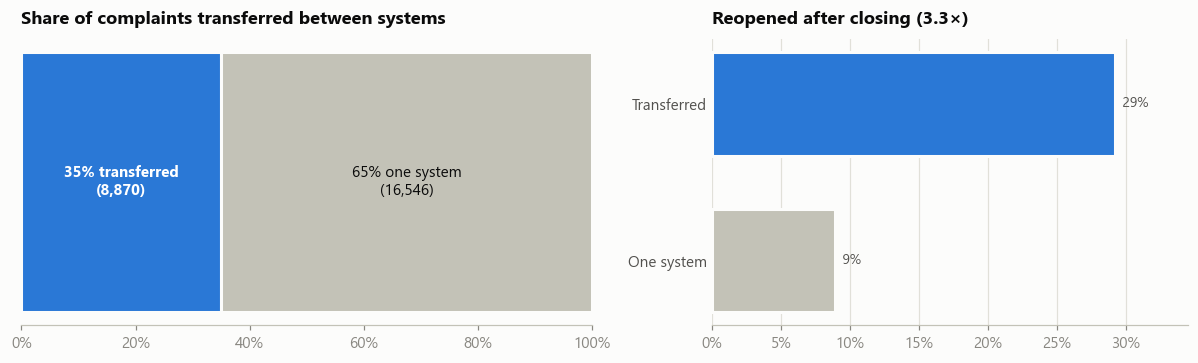

In [12]:
n_tr = int(complaints.transferred_between_systems.sum())
n_one = n_complaints - n_tr
tr_share = n_tr / n_complaints

closed = complaints[complaints.status != "Open"]
reopen = closed.groupby("transferred_between_systems").reopened.mean()
reopen_ratio = reopen[1] / reopen[0]

summary = pd.DataFrame({
    "complaints": complaints.transferred_between_systems.value_counts().sort_index(),
    "share of all": complaints.transferred_between_systems.value_counts(normalize=True).sort_index(),
    "closed": closed.transferred_between_systems.value_counts().sort_index(),
    "reopened": closed.groupby("transferred_between_systems").reopened.sum(),
    "reopen rate (of closed)": reopen,
}).rename(index={0: "Handled in one system", 1: "Transferred between systems"})
display(summary.style.format({"share of all": "{:.1%}", "reopen rate (of closed)": "{:.1%}"}))
print(f"Reopen ratio: {reopen_ratio:.2f}×  (all-complaints basis: "
      f"{complaints.groupby('transferred_between_systems').reopened.mean().pipe(lambda s: s[1] / s[0]):.2f}×)")

claim("Problem slide / TransferChart", "Share transferred between systems", f"{tr_share:.1%}", "35% (34.9)", round(tr_share * 100, 1) == 34.9)
claim("TransferChart", "Transferred complaints", f"{n_tr:,}", "8,870", n_tr == 8870)
claim("TransferChart", "One-system complaints", f"{n_one:,}", "16,546", n_one == 16546)
claim("TransferChart", "Reopen rate, transferred (of closed)", f"{reopen[1]:.1%}", "29%", round(reopen[1] * 100) == 29)
claim("TransferChart", "Reopen rate, one system (of closed)", f"{reopen[0]:.1%}", "9%", round(reopen[0] * 100) == 9)
claim("Problem slide", "Transferred complaints reopen …", f"{reopen_ratio:.2f}×", "3× as often", round(reopen_ratio) == 3)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1.2, 1]})
a1.barh([0], [tr_share], color=BLUE, height=0.5, edgecolor=SURFACE, linewidth=2)
a1.barh([0], [1 - tr_share], left=[tr_share], color=DEEMPH, height=0.5, edgecolor=SURFACE, linewidth=2)
a1.text(tr_share / 2, 0, f"{tr_share:.0%} transferred\n({n_tr:,})", ha="center", va="center", color="white", fontweight="bold")
a1.text(tr_share + (1 - tr_share) / 2, 0, f"{1 - tr_share:.0%} one system\n({n_one:,})", ha="center", va="center", color=INK)
a1.set_xlim(0, 1); a1.set_yticks([]); a1.grid(False); pct_axis(a1, "x")
a1.set_title("Share of complaints transferred between systems")
hbar(a2, ["Transferred", "One system"], [reopen[1], reopen[0]], emphasis=lambda l: l == "Transferred", fmt="{:.0%}")
pct_axis(a2, "x"); a2.set_title(f"Reopened after closing ({reopen_ratio:.1f}×)")
plt.tight_layout(); plt.show()

**Where do transfers come from?** Complaints logged in CaseTrack (SYS-04, the case system) are never transferred;
those that start in Aurora Billing, Northwind Connect or CallCentre One are transferred ~46 % of the time — the
argument for one shared case record.

,complaints,transfer_rate,reopen_rate,sla_breach_rate
SYS-01 Aurora Billing,6479,47.1%,16.9%,79.4%
SYS-03 Northwind Connect,6282,46.4%,16.7%,78.3%
SYS-04 CaseTrack,6281,0.0%,8.8%,71.0%
SYS-05 CallCentre One,6374,45.6%,16.8%,78.4%


Avg days to close — transferred 38.2 vs one system 23.0
SLA breach rate — transferred 88.7% vs one system 70.4%


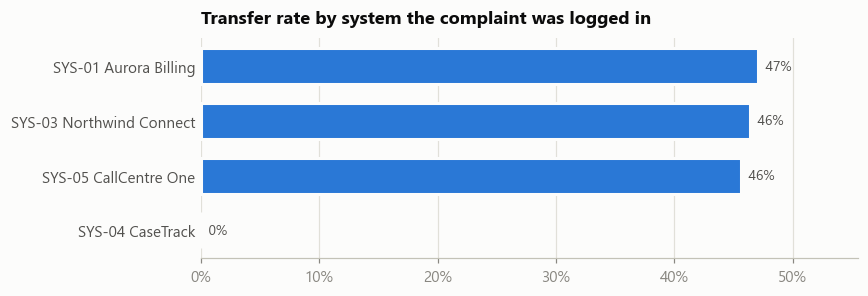

In [13]:
sys_names = systems.set_index("system_id").system_name
by_src = complaints.groupby("source_system").agg(complaints=("complaint_id", "size"),
                                                 transfer_rate=("transferred_between_systems", "mean"),
                                                 reopen_rate=("reopened", "mean"),
                                                 sla_breach_rate=("sla_breach", "mean"))
by_src.index = [f"{i} {sys_names[i]}" for i in by_src.index]
display(by_src.style.format({"transfer_rate": "{:.1%}", "reopen_rate": "{:.1%}", "sla_breach_rate": "{:.1%}"}))

tr_days = closed.groupby("transferred_between_systems").days_to_close.mean()
tr_breach = complaints.groupby("transferred_between_systems").sla_breach.mean()
print(f"Avg days to close — transferred {tr_days[1]:.1f} vs one system {tr_days[0]:.1f}")
print(f"SLA breach rate — transferred {tr_breach[1]:.1%} vs one system {tr_breach[0]:.1%}")

fig, ax = plt.subplots(figsize=(8, 2.8))
s = by_src.transfer_rate.sort_values(ascending=False)
hbar(ax, s.index, s.values, fmt="{:.0%}"); pct_axis(ax, "x")
ax.set_title("Transfer rate by system the complaint was logged in")
plt.tight_layout(); plt.show()

### 2.3 “51 % of complaints are about billing”
Category counts behind `BillingShareChart` (the slide groups Payment + Water + Other into “Other”).

,complaints,share
category,,
Billing - disputed amount,8060,31.7%
Billing - estimated read,4833,19.0%
Metering - no read taken,3120,12.3%
Supply - interruption,2192,8.6%
Service - poor communication,1908,7.5%
Service - missed appointment,1718,6.8%
Payment - plan or arrears,1601,6.3%
Water - pressure or quality,1313,5.2%
Other,671,2.6%


,complaints,"% (rounded, as on slide)"
category,,
Billing,12893,51
Service,3626,14
Metering,3120,12
Supply,2192,9
Other,3585,14


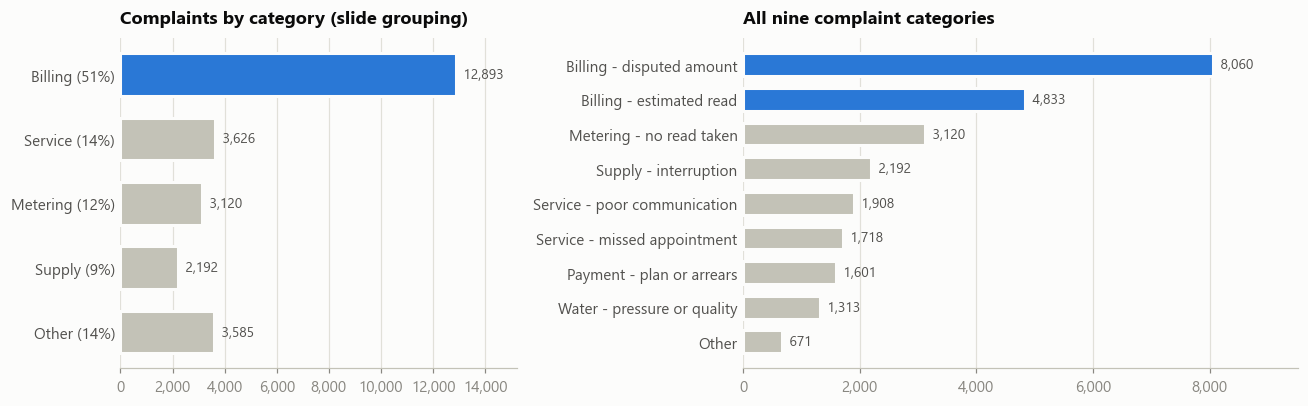

In [14]:
cat_counts = complaints.category.value_counts()
display(cat_counts.to_frame("complaints").assign(share=lambda d: (d.complaints / n_complaints).map("{:.1%}".format)))

family = complaints.category.str.split(" - ").str[0]
slide_group = family.where(family.isin(["Billing", "Service", "Metering", "Supply"]), "Other")
grouped = slide_group.value_counts().reindex(["Billing", "Service", "Metering", "Supply", "Other"])
grouped_pct = (grouped / n_complaints * 100).round().astype(int)
display(pd.DataFrame({"complaints": grouped, "% (rounded, as on slide)": grouped_pct}))

shown = {"Billing": 12893, "Service": 3626, "Metering": 3120, "Supply": 2192, "Other": 3585}
for k, v in shown.items():
    claim("BillingShareChart", f"{k} complaints", f"{grouped[k]:,}", f"{v:,}", grouped[k] == v)
claim("Problem slide", "Share of complaints about billing", f"{grouped['Billing'] / n_complaints:.1%}", "51%", grouped_pct["Billing"] == 51)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.4]})
hbar(a1, [f"{k} ({p}%)" for k, p in grouped_pct.items()], grouped.values, emphasis=lambda l: l.startswith("Billing"))
a1.set_title("Complaints by category (slide grouping)")
hbar(a2, cat_counts.index, cat_counts.values, emphasis=lambda l: l.startswith("Billing"))
a2.set_title("All nine complaint categories")
plt.tight_layout(); plt.show()

## 3. Data Findings slide — one root cause per file
### 3.1 [A] “1,718 complaints are missed appointments, and 71 % of those breach SLA” → *Appointment calendar*

Missed-appointment complaints: 1,718  |  SLA breach rate: 71.2%


,resolution
resolution_action,
Appointment rebooked by agent,1087
Compensation payment issued,346
Information provided only,197


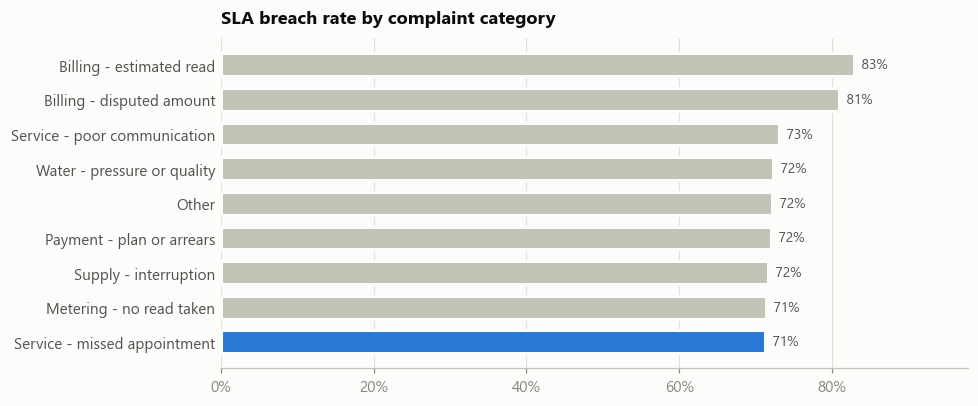

In [15]:
missed = complaints[complaints.category == "Service - missed appointment"]
missed_breach = missed.sla_breach.mean()
print(f"Missed-appointment complaints: {len(missed):,}  |  SLA breach rate: {missed_breach:.1%}")
display(missed.resolution_action.value_counts().to_frame("resolution"))

claim("Data Findings (A)", "Missed-appointment complaints", f"{len(missed):,}", "1,718", len(missed) == 1718)
claim("Data Findings (A)", "Missed appointments breaching SLA", f"{missed_breach:.1%}", "71%", round(missed_breach * 100) == 71)

by_cat = complaints.groupby("category").agg(complaints=("complaint_id", "size"), breach=("sla_breach", "mean")).sort_values("breach", ascending=False)
fig, ax = plt.subplots(figsize=(9, 3.8))
hbar(ax, by_cat.index, by_cat.breach.values, emphasis=lambda l: l == "Service - missed appointment", fmt="{:.0%}")
pct_axis(ax, "x"); ax.set_title("SLA breach rate by complaint category")
plt.tight_layout(); plt.show()

### 3.2 [B] “1998 — COBOL still runs billing, and the REST systems around it aren't linked” → *Bill breakdown, REST API framework*

In [16]:
sy = systems.copy()
sy["age_years (2026)"] = 2026 - sy.year_installed
display(sy[["system_id", "system_name", "year_installed", "age_years (2026)", "tech_stack", "integration_method",
            "annual_run_cost", "owning_function"]].style.format({"annual_run_cost": "${:,.0f}"}))

aurora = sy.set_index("system_id").loc["SYS-01"]
print(f"{aurora.system_name}: installed {aurora.year_installed}, {aurora.tech_stack}, {aurora.integration_method}")
print("  note:", aurora.notes)
claim("Data Findings (B)", "Year billing system (COBOL) installed", str(aurora.year_installed), "1998",
      aurora.year_installed == 1998 and "COBOL" in aurora.tech_stack)

rest = sy[sy.integration_method == "REST API"]
print("\nREST-API systems:", ", ".join(rest.system_name))
integ = sy.groupby("integration_method").agg(systems=("system_id", "size"), run_cost=("annual_run_cost", "sum"))
display(integ.sort_values("systems", ascending=False).style.format({"run_cost": "${:,.0f}"}))
print(f"Total annual IT run cost: ${sy.annual_run_cost.sum():,.0f}")

# Figures quoted from the notes column
connect = sy.set_index("system_id").loc["SYS-03"].notes
callc = sy.set_index("system_id").loc["SYS-05"].notes
print("\nSYS-03 Northwind Connect:", connect)
print("SYS-05 CallCentre One:", callc)
claim("Solution / Staff slides", "Agents use four systems per call", "four (SYS-05 note)", "four systems per call", "four systems" in callc)
claim("Problem slide", "Portal can't break down a bill", "SYS-03 note", "can’t break down a bill", "Cannot display a bill breakdown" in connect)

,system_id,system_name,year_installed,age_years (2026),tech_stack,integration_method,annual_run_cost,owning_function
0,SYS-01,Aurora Billing,1998,28,COBOL / DB2 on mainframe,Nightly batch file,"$4,100,000",Finance IT
1,SYS-02,Helix CIS,2004,22,Oracle Forms / Oracle 11g,Nightly batch file,"$3,250,000",Customer Ops IT
2,SYS-03,Northwind Connect,2019,7,React / Node / Postgres,REST API,"$1,450,000",Digital
3,SYS-04,CaseTrack,2011,15,Java / SQL Server,Nightly batch file,"$980,000",Customer Ops IT
4,SYS-05,CallCentre One,2015,11,SaaS,REST API,"$2,200,000",Customer Ops
5,SYS-06,MeterHub,2009,17,C# / SQL Server,Nightly batch file,"$1,700,000",Metering
6,SYS-07,SmartRead Gateway,2021,5,Kafka / Cassandra,Streaming,"$2,600,000",Metering
7,SYS-08,FieldForce,2013,13,SaaS,REST API,"$1,350,000",Operations
8,SYS-09,GridWatch,2016,10,On-prem appliance,Message queue,"$3,800,000",Network
9,SYS-10,AquaTrack,2007,19,VB.NET / SQL Server,Manual export,"$890,000",Water Ops


Aurora Billing: installed 1998, COBOL / DB2 on mainframe, Nightly batch file
  note: Serves Barrowdale and Dunmoor only. Two remaining developers understand the rating engine.

REST-API systems: Northwind Connect, CallCentre One, FieldForce, PeopleBase, AskNorthwind (pilot)


,systems,run_cost
integration_method,,
REST API,5,"$6,740,000"
Nightly batch file,4,"$10,030,000"
Manual export,3,"$1,890,000"
Batch interface,1,"$5,400,000"
Message queue,1,"$3,800,000"
Streaming,1,"$2,600,000"


Total annual IT run cost: $30,460,000

SYS-03 Northwind Connect: Only 34% of customers registered. Cannot display a bill breakdown.
SYS-05 CallCentre One: Agents run four systems side by side to answer one call.


'SYS-03 note'

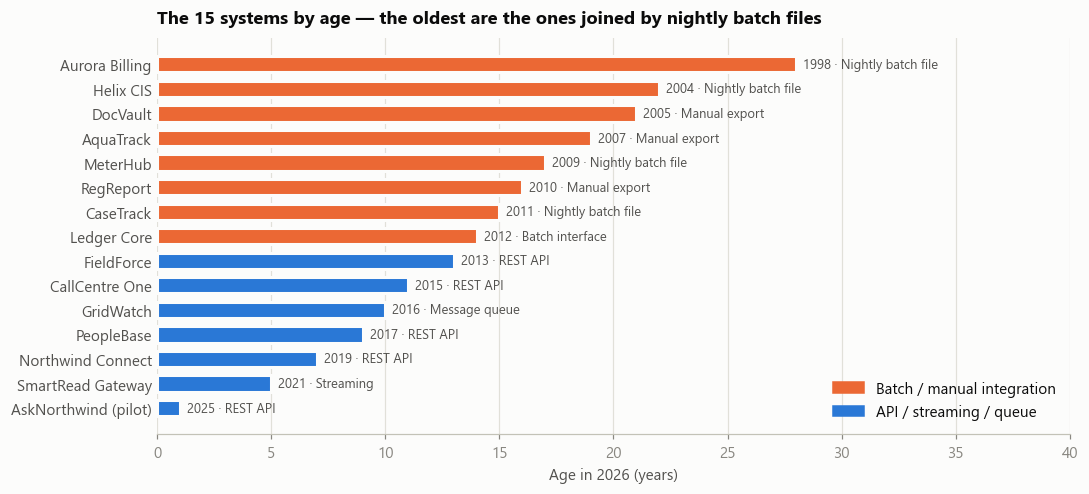

In [17]:
batchy = {"Nightly batch file", "Manual export", "Batch interface"}
sy_sorted = sy.sort_values("year_installed")
colors = [ORANGE if m in batchy else BLUE for m in sy_sorted.integration_method]
fig, ax = plt.subplots(figsize=(10, 4.6))
bars = ax.barh(sy_sorted.system_name, sy_sorted["age_years (2026)"], color=colors, height=0.66, edgecolor=SURFACE, linewidth=2)
ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); ax.tick_params(axis="y", colors=INK_2, length=0)
for b, (_, r) in zip(bars, sy_sorted.iterrows()):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, f"  {r.year_installed} · {r.integration_method}", va="center", color=INK_2, fontsize=8.5)
ax.set_xlim(0, 40); ax.set_xlabel("Age in 2026 (years)")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=ORANGE), plt.Rectangle((0, 0), 1, 1, color=BLUE)],
          labels=["Batch / manual integration", "API / streaming / queue"], loc="lower right")
ax.set_title("The 15 systems by age — the oldest are the ones joined by nightly batch files")
plt.tight_layout(); plt.show()

### 3.3 [E] “10 % of AI-assistant chats were resolved by the end of the pilot; CSAT 2.0/5, now paused” → *RAG pipeline*

In [18]:
display(ai_pilot.style.format({c: "{:.1%}" for c in ai_pilot.columns if c.endswith("_rate")}))
end, start = ai_pilot.iloc[-1], ai_pilot.iloc[0]
total_sessions = ai_pilot.assistant_sessions.sum()
contained_sessions = (ai_pilot.assistant_sessions * ai_pilot.fully_contained_rate).sum()
escalated_sessions = (ai_pilot.assistant_sessions * ai_pilot.escalated_to_agent_rate).sum()
complaints_after = (ai_pilot.assistant_sessions * ai_pilot.complaint_raised_after_session_rate).sum()
pilot_cost = unit_costs.set_index("item").loc["AskNorthwind assistant pilot", "unit_cost"] * 9 / 12

print(f"Containment {start.fully_contained_rate:.1%} (Jan) → {end.fully_contained_rate:.1%} (Sep 2025)")
print(f"CSAT {start.assistant_csat_of_5} → {end.assistant_csat_of_5} / 5")
print(f"Repeat contact within 7 days {start.repeat_contact_within_7_days_rate:.0%} → {end.repeat_contact_within_7_days_rate:.0%}")
print(f"Pilot totals: {total_sessions:,} sessions, {contained_sessions:,.0f} fully contained "
      f"({contained_sessions / total_sessions:.1%}), {escalated_sessions:,.0f} escalated to an agent, "
      f"{complaints_after:,.0f} led to a complaint")
print(f"9-month pilot cost ≈ ${pilot_cost:,.0f} → ${pilot_cost / contained_sessions:,.2f} per fully contained session "
      f"(vs ${unit_costs.set_index('item').loc['Inbound call handled by agent', 'unit_cost']} per agent-handled call)")
print("SYS-15 note:", systems.set_index("system_id").loc["SYS-15"].notes)

claim("Data Findings (E)", "AI chats fully contained, Sep 2025", f"{end.fully_contained_rate:.1%}", "10%", round(end.fully_contained_rate * 100) == 10)
claim("Data Findings (E)", "Assistant CSAT, Sep 2025", f"{end.assistant_csat_of_5:.2f} / 5", "2.0/5", round(end.assistant_csat_of_5, 1) == 2.0)
claim("Data Findings (E)", "Pilot status", "Paused (SYS-15 note)", "now paused", "Paused" in systems.set_index("system_id").loc["SYS-15"].notes)

,month,assistant_sessions,fully_contained_rate,escalated_to_agent_rate,abandoned_rate,repeat_contact_within_7_days_rate,assistant_csat_of_5,complaint_raised_after_session_rate
0,2025-01,14775,16.0%,77.0%,7.0%,31.0%,2.600000,11.0%
1,2025-02,13685,15.3%,77.7%,7.0%,32.7%,2.530000,11.4%
2,2025-03,15773,14.6%,78.4%,7.0%,34.4%,2.460000,11.8%
3,2025-04,18069,13.9%,79.1%,7.0%,36.1%,2.390000,12.2%
4,2025-05,18791,13.2%,79.8%,7.0%,37.8%,2.320000,12.6%
5,2025-06,18766,12.5%,80.5%,7.0%,39.5%,2.250000,13.0%
6,2025-07,20133,11.8%,81.2%,7.0%,41.2%,2.180000,13.4%
7,2025-08,19890,11.1%,81.9%,7.0%,42.9%,2.110000,13.8%
8,2025-09,20780,10.4%,82.6%,7.0%,44.6%,2.040000,14.2%


Containment 16.0% (Jan) → 10.4% (Sep 2025)
CSAT 2.6 → 2.04 / 5
Repeat contact within 7 days 31% → 45%
Pilot totals: 160,662 sessions, 20,843 fully contained (13.0%), 128,573 escalated to an agent, 20,452 led to a complaint
9-month pilot cost ≈ $480,000 → $23.03 per fully contained session (vs $7.4 per agent-handled call)
SYS-15 note: Nine-month pilot, Jan-Sep 2025. Paused. Results in northwind_ai_pilot_2025.csv.


'Paused (SYS-15 note)'

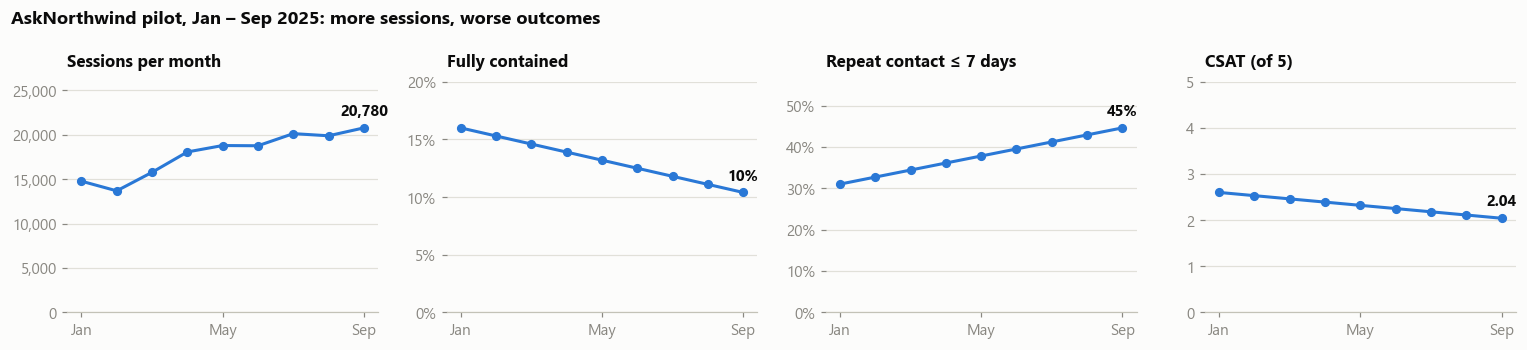

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
x = np.arange(len(ai_pilot)); months = ai_pilot.month.tolist()
panels = [("assistant_sessions", "Sessions per month", None),
          ("fully_contained_rate", "Fully contained", "pct"),
          ("repeat_contact_within_7_days_rate", "Repeat contact ≤ 7 days", "pct"),
          ("assistant_csat_of_5", "CSAT (of 5)", None)]
for ax, (col, title, kind) in zip(axes, panels):
    ax.plot(x, ai_pilot[col], color=BLUE, marker="o")
    ax.set_title(title, fontsize=11)
    ax.set_xticks([0, 4, 8]); ax.set_xticklabels([pd.Period(months[i]).strftime("%b") for i in (0, 4, 8)])
    if kind == "pct": pct_axis(ax)
    ax.set_ylim(0, ai_pilot[col].max() * 1.25)
    if col == "assistant_sessions": ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.annotate(f"{ai_pilot[col].iloc[-1]:.0%}" if kind == "pct" else f"{ai_pilot[col].iloc[-1]:,.2f}".rstrip("0").rstrip("."),
                (x[-1], ai_pilot[col].iloc[-1]), textcoords="offset points", xytext=(0, 8), ha="center", fontweight="bold")
axes[3].set_ylim(0, 5)
fig.suptitle("AskNorthwind pilot, Jan – Sep 2025: more sessions, worse outcomes", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

### 3.4 [G] “41 % attrition in Calderfield, with 32 vacancies and 5.5 complaints per agent” → *Staff data analysis*

In [20]:
latest = staffing.month.max()
cal = staffing[(staffing.region == "Calderfield") & (staffing.month == latest)].iloc[0]
display(staffing[staffing.month == latest].set_index("region").drop(columns="month")
        .style.format({"attrition_rate_12m": "{:.1%}"}))
display(Markdown("**Calderfield timeline (notes column)**"))
display(staffing[(staffing.region == "Calderfield") & staffing.note.notna()][["month", "agent_fte", "open_vacancies",
        "attrition_rate_12m", "complaints_opened_per_agent", "note"]])

others = staffing[(staffing.month == latest) & (staffing.region != "Calderfield")]
print(f"Calderfield vs other regions ({latest}): attrition {cal.attrition_rate_12m:.1%} vs {others.attrition_rate_12m.mean():.1%} avg; "
      f"vacancies {cal.open_vacancies} vs {others.open_vacancies.mean():.1f}; complaints/agent {cal.complaints_opened_per_agent} vs "
      f"{others.complaints_opened_per_agent.mean():.1f}")
cal_start = staffing[(staffing.region == "Calderfield")].iloc[0]
print(f"Calderfield agent FTE {cal_start.agent_fte} ({cal_start.month}) → {cal.agent_fte} ({latest}): "
      f"{cal.agent_fte / cal_start.agent_fte - 1:.0%}")

claim("Data Findings (G) / Impact", "Calderfield 12-month attrition", f"{cal.attrition_rate_12m:.1%}", "41%", round(cal.attrition_rate_12m * 100) == 41)
claim("Data Findings (G)", "Calderfield open vacancies", str(cal.open_vacancies), "32", cal.open_vacancies == 32)
claim("Data Findings (G)", "Calderfield complaints per agent", str(cal.complaints_opened_per_agent), "5.5", cal.complaints_opened_per_agent == 5.5)

,agent_fte,open_vacancies,attrition_rate_12m,complaints_opened_per_agent,note
region,,,,,
Ashford,81,4,15.1%,2.300000,nan
Barrowdale,64,3,16.6%,2.900000,nan
Calderfield,37,32,40.9%,5.500000,Recruitment freeze; vacancies unfilled
Dunmoor,49,3,10.4%,3.800000,nan
Eastmarch,60,2,15.3%,3.400000,nan
Fenwick,42,2,12.7%,4.000000,nan


**Calderfield timeline (notes column)**

,month,agent_fte,open_vacancies,attrition_rate_12m,complaints_opened_per_agent,note
92,2026-01,63,4,0.287,3.3,Attrition rising; two team leads resigned
98,2026-02,63,3,0.300,2.6,Attrition rising; two team leads resigned
104,2026-03,38,32,0.397,5.2,Recruitment freeze; vacancies unfilled
110,2026-04,38,32,0.403,5.1,Recruitment freeze; vacancies unfilled
116,2026-05,38,32,0.460,4.8,Recruitment freeze; vacancies unfilled
122,2026-06,38,32,0.454,4.8,Recruitment freeze; vacancies unfilled
128,2026-07,37,32,0.418,6.2,Recruitment freeze; vacancies unfilled
134,2026-08,37,32,0.409,5.1,Recruitment freeze; vacancies unfilled
140,2026-09,37,32,0.409,5.5,Recruitment freeze; vacancies unfilled


Calderfield vs other regions (2026-09): attrition 40.9% vs 14.0% avg; vacancies 32 vs 2.8; complaints/agent 5.5 vs 3.3
Calderfield agent FTE 73 (2024-10) → 37 (2026-09): -49%


'5.5'

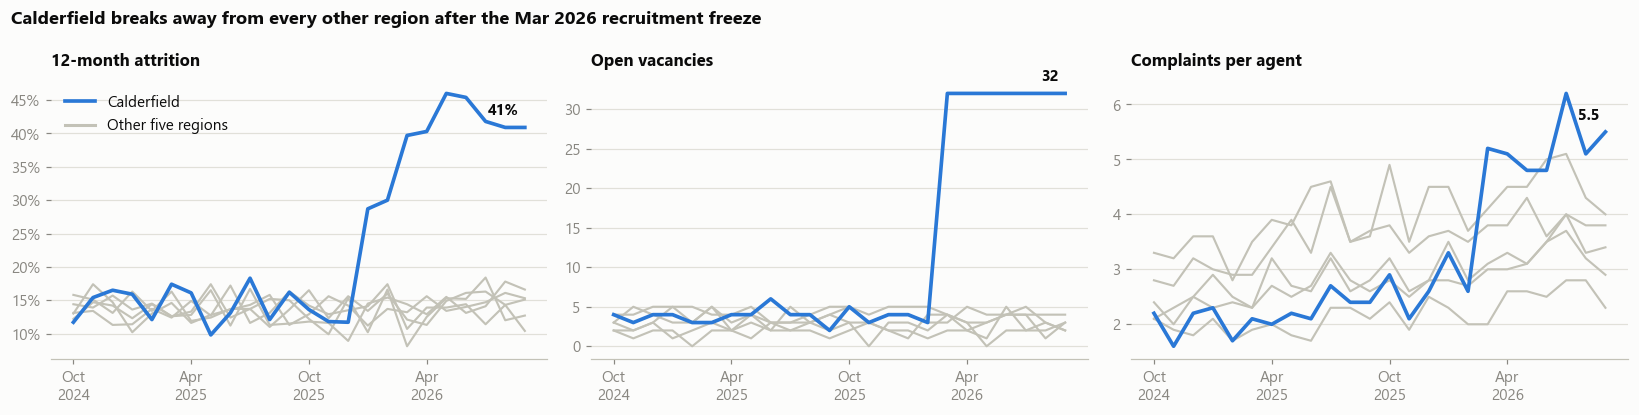

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
months = sorted(staffing.month.unique())
for ax, (col, title, kind) in zip(axes, [("attrition_rate_12m", "12-month attrition", "pct"),
                                         ("open_vacancies", "Open vacancies", None),
                                         ("complaints_opened_per_agent", "Complaints per agent", None)]):
    for region, g in staffing.groupby("region"):
        is_cal = region == "Calderfield"
        ax.plot(np.arange(len(g)), g[col], color=EMPHASIS if is_cal else DEEMPH, lw=2.4 if is_cal else 1.4,
                zorder=3 if is_cal else 2, label="Calderfield" if is_cal else None)
    ax.set_title(title, fontsize=11); month_ticks(ax, months, every=6)
    if kind == "pct": pct_axis(ax)
    last = staffing[(staffing.region == "Calderfield") & (staffing.month == latest)][col].iloc[0]
    ax.annotate(f"{last:.0%}" if kind == "pct" else f"{last:g}", (len(months) - 1, last), textcoords="offset points",
                xytext=(-4, 8), ha="right", fontweight="bold")
axes[0].plot([], [], color=DEEMPH, label="Other five regions"); axes[0].legend(loc="upper left")
fig.suptitle("Calderfield breaks away from every other region after the Mar 2026 recruitment freeze", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

## 4. Impact slide
### 4.1 “No more hand-offs … worth up to ~$235K a year”
Footnote: *~4,435 transfers a year × $53 extra each ($121 vs $68 per complaint, Northwind FY26 cost model)*.

,item,unit_cost,unit,source_note
0,Inbound call handled by agent,7.4,per call,Finance cost model FY26
1,Complaint handled end to end (average),68.0,per complaint,"Finance cost model FY26, fully loaded"
2,Complaint handled end to end (transferred betw...,121.0,per complaint,Finance cost model FY26
3,Manual bill correction and re-issue,34.0,per correction,Finance cost model FY26
4,Field meter visit,92.0,per visit,"Operations, FY26 actuals"
5,Smart meter installation,148.0,per meter,"SYS-07 rollout actuals, Ashford"
6,"Contact centre agent, fully loaded",46000.0,per FTE per year,"HR, FY26"
7,AskNorthwind assistant pilot,640000.0,per year,"SYS-15 vendor contract, 2025"
8,"Regulator penalty, enhanced monitoring",2400000.0,per quarter in breach,Regulatory Affairs estimate
9,"Compensation payment, missed appointment or ou...",40.0,per case,Regulated standard


Data spans 2.00 years (24 months). Transfers per year: 8,870 / 2 = 4,435
Extra cost per transfer: $121 − $68 = $53
Annual avoidable cost: 4,435 × $53 = $235,055

(Sensitivity) Implied one-system cost if $68 is the blended average: $39.59 → $361,064/yr


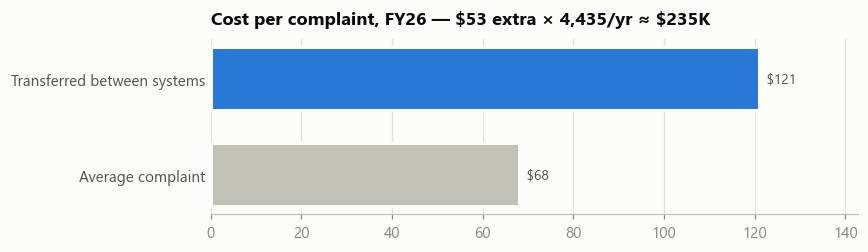

In [22]:
uc = unit_costs.set_index("item").unit_cost
display(unit_costs)
cost_avg = uc["Complaint handled end to end (average)"]
cost_tr = uc["Complaint handled end to end (transferred between systems)"]
extra = cost_tr - cost_avg
years = (complaints.date_opened.max() - complaints.date_opened.min()).days / 365.25
per_year = n_tr / 2  # 24 months of data
saving = per_year * extra
print(f"Data spans {years:.2f} years (24 months). Transfers per year: {n_tr:,} / 2 = {per_year:,.0f}")
print(f"Extra cost per transfer: ${cost_tr:.0f} − ${cost_avg:.0f} = ${extra:.0f}")
print(f"Annual avoidable cost: {per_year:,.0f} × ${extra:.0f} = ${saving:,.0f}")

# A stricter variant: compare against the cost of a *one-system* complaint rather than the blended average
cost_one = (cost_avg * n_complaints - cost_tr * n_tr) / n_one
print(f"\n(Sensitivity) Implied one-system cost if $68 is the blended average: ${cost_one:.2f} → "
      f"${per_year * (cost_tr - cost_one):,.0f}/yr")

claim("Impact footnote", "Transfers per year", f"{per_year:,.0f}", "~4,435", per_year == 4435)
claim("Impact footnote", "Extra cost per transferred complaint", f"${extra:.0f}", "$53", extra == 53)
claim("Impact slide", "Annual cost of hand-offs", f"${saving:,.0f}", "~$235K", round(saving / 1000) == 235)

fig, ax = plt.subplots(figsize=(8, 2.4))
hbar(ax, ["Transferred between systems", "Average complaint"], [cost_tr, cost_avg],
     emphasis=lambda l: l.startswith("Transferred"), fmt="${:,.0f}")
ax.set_title(rf"Cost per complaint, FY26 — \${extra:.0f} extra × {per_year:,.0f}/yr ≈ \${saving / 1000:,.0f}K")
plt.tight_layout(); plt.show()

### 4.2 “Billing questions answered up front: 23 % of complaints only needed information”
`resolvable_by_information_only` is flagged on closed complaints; the slide expresses it as a share of **all** complaints.

Resolvable by information only: 5,865 → 23.1% of all complaints (24.6% of closed ones)
Resolution recorded as 'Information provided only': 4,783
Billing complaints resolvable by information only: 2,654 (22.2% of closed billing)
Cost of those at $68 each: $398,820 over two years


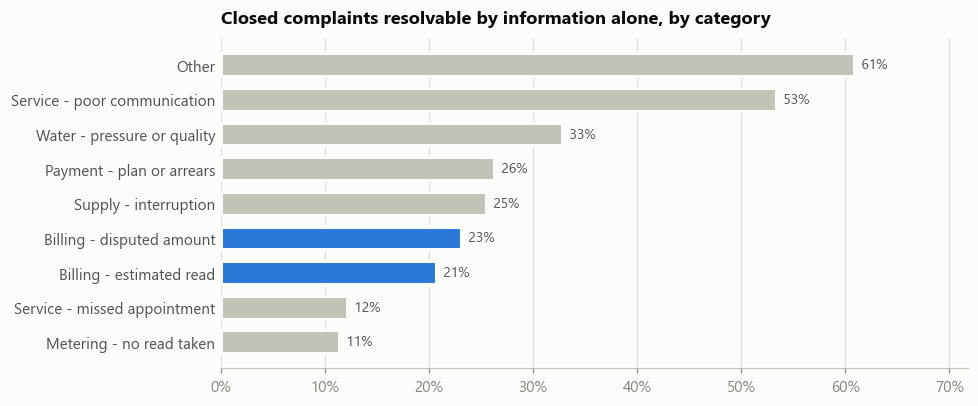

In [23]:
info_n = int((complaints.resolvable_by_information_only == 1).sum())
info_all = info_n / n_complaints
info_closed = complaints.resolvable_by_information_only.mean()  # NaN (open) rows excluded
print(f"Resolvable by information only: {info_n:,} → {info_all:.1%} of all complaints ({info_closed:.1%} of closed ones)")
print(f"Resolution recorded as 'Information provided only': {(complaints.resolution_action == 'Information provided only').sum():,}")
billing_info = complaints[complaints.category.str.startswith("Billing")].resolvable_by_information_only
print(f"Billing complaints resolvable by information only: {int(billing_info.sum()):,} ({billing_info.mean():.1%} of closed billing)")
print(f"Cost of those at $68 each: ${info_n * cost_avg:,.0f} over two years")

claim("Impact slide", "Complaints that only needed information", f"{info_all:.1%}", "23%", round(info_all * 100) == 23)

by_cat_info = complaints.groupby("category").resolvable_by_information_only.mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 3.8))
hbar(ax, by_cat_info.index, by_cat_info.values, emphasis=lambda l: l.startswith("Billing"), fmt="{:.0%}")
pct_axis(ax, "x"); ax.set_title("Closed complaints resolvable by information alone, by category")
plt.tight_layout(); plt.show()

### 4.3 “Assign requests and track SLAs (77 % breached today)”

SLA breached: 19,519 of 25,416 = 76.8% (closed only: 75.4%; still-open past SLA: 98.1%)


,sla_days,complaints,breach,avg_days
priority,,,,
P1,5,1533,72.0%,8.5
P2,10,6017,76.0%,17.2
P3,20,17866,77.5%,33.8


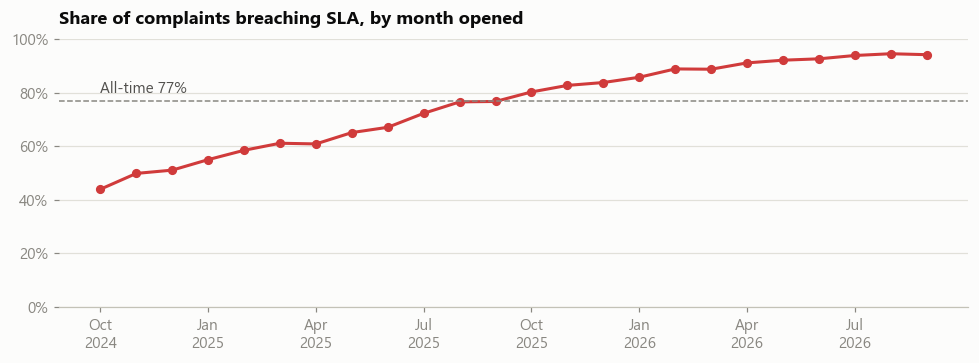

In [24]:
breach_all = complaints.sla_breach.mean()
print(f"SLA breached: {int(complaints.sla_breach.sum()):,} of {n_complaints:,} = {breach_all:.1%} "
      f"(closed only: {closed.sla_breach.mean():.1%}; still-open past SLA: {complaints[open_mask].sla_breach.mean():.1%})")
claim("Impact slide", "Complaints breaching SLA", f"{breach_all:.1%}", "77%", round(breach_all * 100) == 77)

pr = complaints.groupby("priority").agg(sla_days=("sla_days", "first"), complaints=("complaint_id", "size"),
                                        breach=("sla_breach", "mean"), avg_days=("days_to_close", "mean")).round(3)
display(pr.style.format({"breach": "{:.1%}", "avg_days": "{:.1f}"}))

monthly_breach = complaints.groupby("open_month").sla_breach.mean()
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(np.arange(len(monthly_breach)), monthly_breach.values, color=CRITICAL, marker="o")
month_ticks(ax, monthly_breach.index.tolist()); pct_axis(ax); ax.set_ylim(0, 1)
ax.axhline(breach_all, color=MUTED, lw=1, ls="--"); ax.text(0, breach_all + 0.03, f"All-time {breach_all:.0%}", color=INK_2)
ax.set_title("Share of complaints breaching SLA, by month opened")
plt.tight_layout(); plt.show()

## 5. Manager dashboard — `StaffingDashboard.tsx` calculations
The dashboard's `summarize()` sums FTE and vacancies and **FTE-weights** attrition and complaints per agent, then shows
the change against the previous month. Reproduced here for the latest month, all regions.

In [25]:
def summarize(rows):
    agents = rows.agent_fte.sum()
    return pd.Series({
        "Agent FTE": agents,
        "Open vacancies": rows.open_vacancies.sum(),
        "12 month attrition": (rows.attrition_rate_12m * rows.agent_fte).sum() / agents if agents else 0,
        "Complaints per agent": (rows.complaints_opened_per_agent * rows.agent_fte).sum() / agents if agents else 0,
    })

months = sorted(staffing.month.unique())
cur, prev = summarize(staffing[staffing.month == months[-1]]), summarize(staffing[staffing.month == months[-2]])
tiles = pd.DataFrame({months[-1]: cur, months[-2]: prev, "change": cur - prev})
display(tiles.style.format("{:,.3f}"))
print(f"Tiles as the dashboard renders them ({months[-1]}, all regions):")
print(f"  Agent FTE {cur['Agent FTE']:,.0f} ({cur['Agent FTE'] - prev['Agent FTE']:+,.0f} vs previous month)")
print(f"  Open vacancies {cur['Open vacancies']:,.0f} ({cur['Open vacancies'] - prev['Open vacancies']:+,.0f})")
print(f"  12 month attrition {cur['12 month attrition']:.1%} ({(cur['12 month attrition'] - prev['12 month attrition']) * 100:+.1f} percentage points)")
print(f"  Complaints per agent {cur['Complaints per agent']:.1f} ({cur['Complaints per agent'] - prev['Complaints per agent']:+.1f})")

network = staffing.groupby("month").apply(summarize, include_groups=False)
print(f"\nNetwork agent FTE {network['Agent FTE'].iloc[0]:.0f} ({months[0]}) → {network['Agent FTE'].iloc[-1]:.0f} ({months[-1]}); "
      f"vacancies {network['Open vacancies'].iloc[0]:.0f} → {network['Open vacancies'].iloc[-1]:.0f}")
print(f"Complaints opened per FTE-month (network, weighted) {network['Complaints per agent'].iloc[0]:.2f} → {network['Complaints per agent'].iloc[-1]:.2f}")

,2026-09,2026-08,change
Agent FTE,333.000,334.000,-1.000
Open vacancies,46.000,45.000,1.000
12 month attrition,0.173,0.179,-0.006
Complaints per agent,3.404,3.561,-0.157


Tiles as the dashboard renders them (2026-09, all regions):
  Agent FTE 333 (-1 vs previous month)
  Open vacancies 46 (+1)
  12 month attrition 17.3% (-0.6 percentage points)
  Complaints per agent 3.4 (-0.2)

Network agent FTE 380 (2024-10) → 333 (2026-09); vacancies 18 → 46
Complaints opened per FTE-month (network, weighted) 2.40 → 3.40


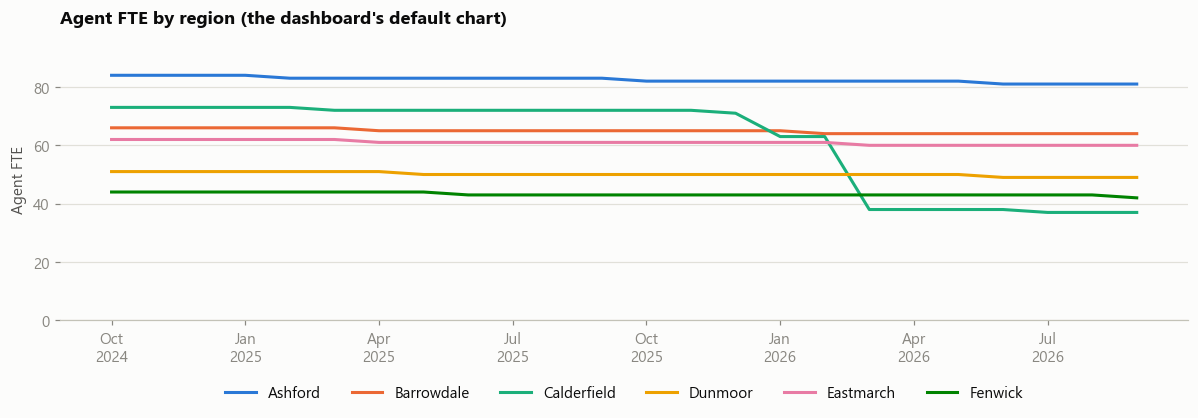

In [26]:
fig, ax = plt.subplots(figsize=(11, 4))
for region, g in staffing.groupby("region"):
    ax.plot(np.arange(len(g)), g.agent_fte.values, color=REGION_COLOR[region], label=region)
month_ticks(ax, months); ax.set_ylim(0, staffing.agent_fte.max() * 1.15); ax.set_ylabel("Agent FTE")
ax.legend(ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.18))
ax.set_title("Agent FTE by region (the dashboard's default chart)")
plt.tight_layout(); plt.show()

## 6. Supporting analysis
The context behind the narrative — trends the slides summarise in a sentence.
### 6.1 Monthly KPI trends (C)

In [27]:
first_k, last_k = kpis.iloc[0], kpis.iloc[-1]
change = pd.DataFrame({"Oct 2024": first_k, "Sep 2026": last_k}).drop("month").astype(float)
change["change"] = change["Sep 2026"] - change["Oct 2024"]
change["% change"] = change["change"] / change["Oct 2024"]
display(change.style.format({"Oct 2024": "{:,.2f}", "Sep 2026": "{:,.2f}", "change": "{:+,.2f}", "% change": "{:+.1%}"}))

corr = kpis.drop(columns="month").corr().round(2)
display(Markdown("**Correlation between monthly KPIs**"))
display(corr.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))

,Oct 2024,Sep 2026,change,% change
complaints_opened,912.00,"1,251.00",+339.00,+37.2%
complaints_closed,476.00,"1,162.00",+686.00,+144.1%
avg_days_to_close,9.10,38.20,+29.10,+319.8%
first_contact_resolution_rate,0.62,0.41,-0.21,-33.4%
inbound_calls,"42,571.00","57,060.00","+14,489.00",+34.0%
cost_to_serve_per_account,18.73,23.92,+5.19,+27.7%
regulator_satisfaction_score_of_5,4.30,2.58,-1.72,-40.0%


**Correlation between monthly KPIs**

,complaints_opened,complaints_closed,avg_days_to_close,first_contact_resolution_rate,inbound_calls,cost_to_serve_per_account,regulator_satisfaction_score_of_5
complaints_opened,1.000000,0.720000,0.750000,-0.790000,0.860000,0.720000,-0.790000
complaints_closed,0.720000,1.000000,0.900000,-0.830000,0.780000,0.740000,-0.830000
avg_days_to_close,0.750000,0.900000,1.000000,-0.980000,0.900000,0.900000,-0.980000
first_contact_resolution_rate,-0.790000,-0.830000,-0.980000,1.000000,-0.950000,-0.940000,1.000000
inbound_calls,0.860000,0.780000,0.900000,-0.950000,1.000000,0.860000,-0.950000
cost_to_serve_per_account,0.720000,0.740000,0.900000,-0.940000,0.860000,1.000000,-0.940000
regulator_satisfaction_score_of_5,-0.790000,-0.830000,-0.980000,1.000000,-0.950000,-0.940000,1.000000


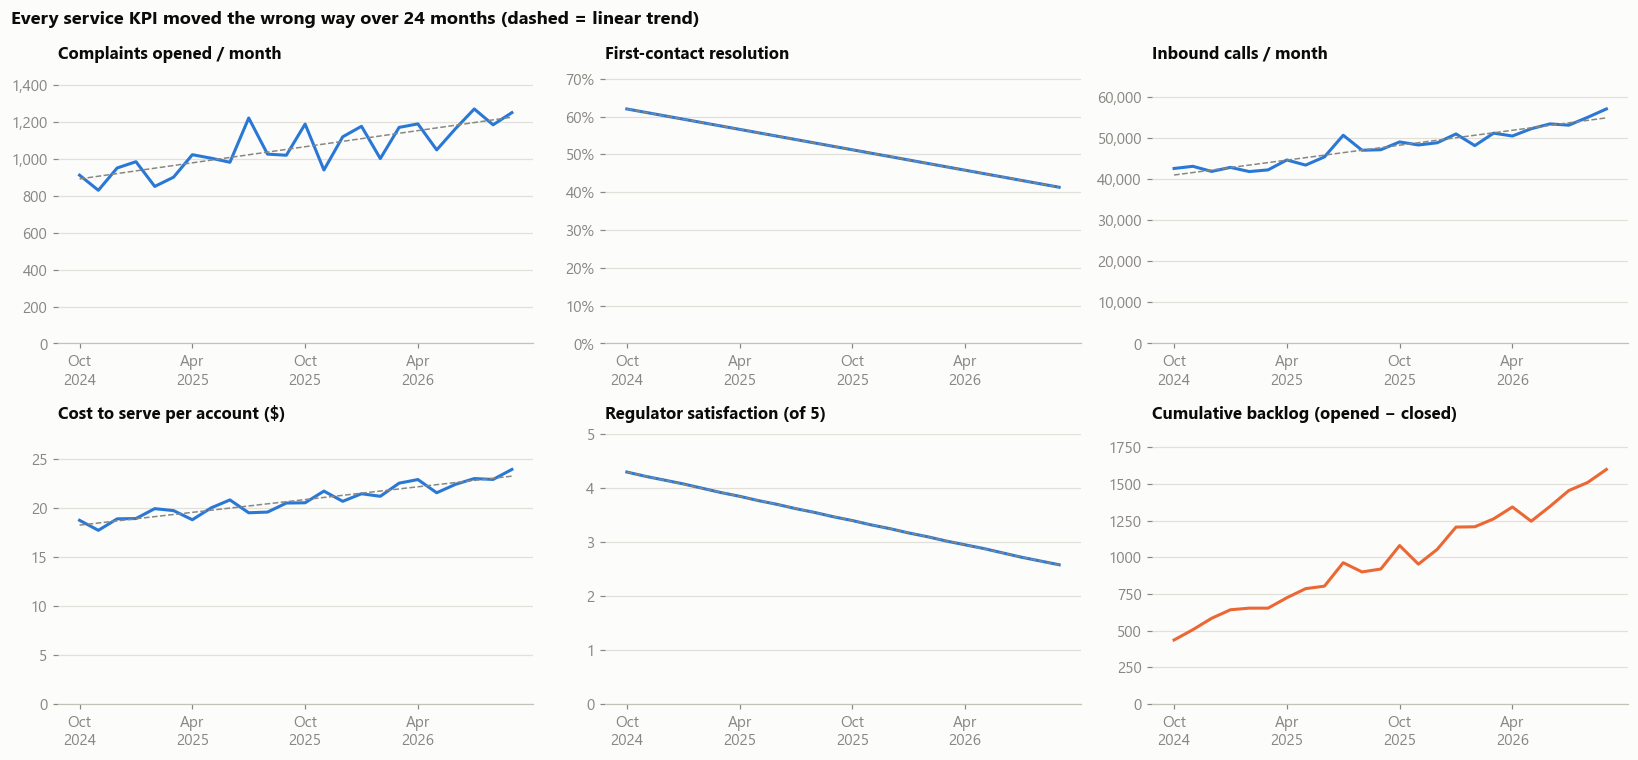

Backlog at Sep 2026: 1,599 (= open complaints in A: 1,599)


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
x = np.arange(len(kpis)); m = kpis.month.tolist()
panels = [
    ("complaints_opened", "Complaints opened / month", None),
    ("first_contact_resolution_rate", "First-contact resolution", "pct"),
    ("inbound_calls", "Inbound calls / month", None),
    ("cost_to_serve_per_account", "Cost to serve per account ($)", None),
    ("regulator_satisfaction_score_of_5", "Regulator satisfaction (of 5)", None),
]
for ax, (col, title, kind) in zip(axes.flat, panels):
    ax.plot(x, kpis[col], color=BLUE)
    z = np.polyfit(x, kpis[col], 1); ax.plot(x, np.polyval(z, x), color=MUTED, lw=1, ls="--")
    ax.set_title(title, fontsize=11); month_ticks(ax, m, every=6)
    if kind == "pct": pct_axis(ax)
    ax.set_ylim(0, kpis[col].max() * 1.15)
    if kind != "pct": ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[1, 1].set_ylim(0, 5)
# Opened vs closed: backlog
ax = axes[1, 2]
backlog = (kpis.complaints_opened - kpis.complaints_closed).cumsum()
ax.plot(x, backlog, color=ORANGE); ax.set_title("Cumulative backlog (opened − closed)", fontsize=11); month_ticks(ax, m, every=6)
ax.set_ylim(0, backlog.max() * 1.15)
fig.suptitle("Every service KPI moved the wrong way over 24 months (dashed = linear trend)", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Backlog at Sep 2026: {backlog.iloc[-1]:,} (= open complaints in A: {int(open_mask.sum()):,})")

In [29]:
# Regulator risk: when does the regulator score cross key thresholds on the current trend?
z = np.polyfit(x, kpis.regulator_satisfaction_score_of_5, 1)
print(f"Regulator score falls {-z[0]:.3f} points per month")
for t in (2.5, 2.0):
    months_ahead = (t - np.polyval(z, x[-1])) / z[0]
    print(f"  Projected to reach {t} about {months_ahead:.0f} month(s) after Sep 2026")
print(f"Regulator penalty (enhanced monitoring): ${uc['Regulator penalty, enhanced monitoring']:,.0f} per quarter in breach")
print(f"Inbound call cost Sep 2026: {last_k.inbound_calls:,.0f} × ${uc['Inbound call handled by agent']} = "
      f"${last_k.inbound_calls * uc['Inbound call handled by agent']:,.0f}/month")

Regulator score falls 0.075 points per month
  Projected to reach 2.5 about 1 month(s) after Sep 2026
  Projected to reach 2.0 about 8 month(s) after Sep 2026
Regulator penalty (enhanced monitoring): $2,400,000 per quarter in breach
Inbound call cost Sep 2026: 57,060 × $7.4 = $422,244/month


### 6.2 Complaint mix — channel, region, priority, resolution (A)

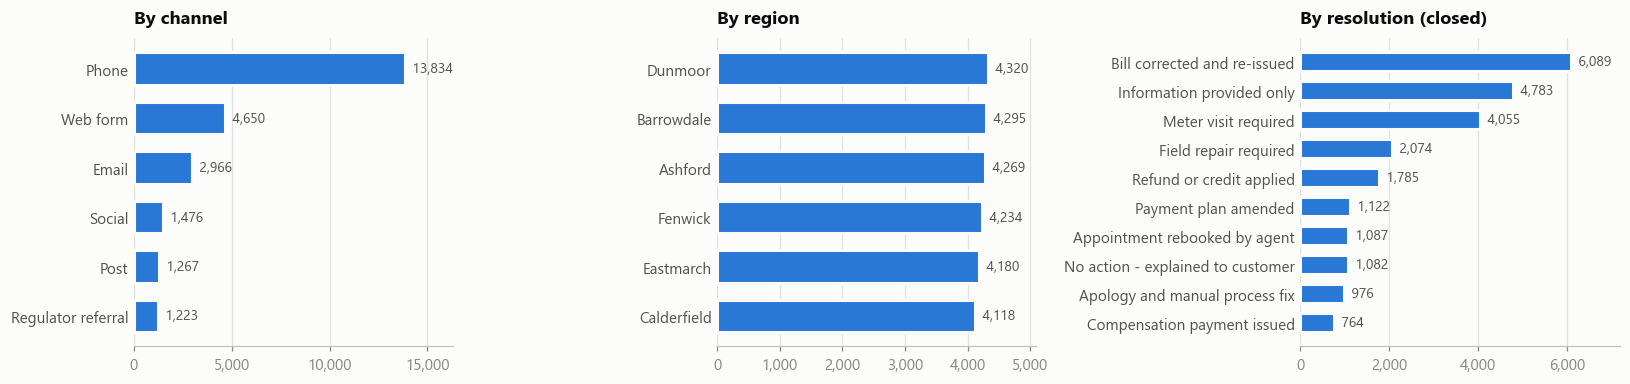

,complaints,transfer_rate,sla_breach,reopen,avg_days,per 1k accounts
region,,,,,,
Ashford,4269,36.2%,76.0%,14.3%,28.2,10.4
Barrowdale,4295,35.9%,77.4%,15.1%,28.7,14.4
Calderfield,4118,34.3%,77.1%,14.9%,27.8,11.6
Dunmoor,4320,34.4%,77.4%,14.7%,28.3,19.5
Eastmarch,4180,34.3%,76.6%,14.9%,28.2,13.8
Fenwick,4234,34.3%,76.3%,15.3%,28.0,20.2


Phone share of complaints: 54.4% | Regulator referrals: 1,223
Bill corrections: 7,874 worth $1,345,190 (median $160.72); manual re-issue cost at $34 each: $267,716


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
ch = complaints.channel.value_counts(); hbar(axes[0], ch.index, ch.values, color=BLUE); axes[0].set_title("By channel")
rg = complaints.region.value_counts(); hbar(axes[1], rg.index, rg.values, color=BLUE); axes[1].set_title("By region")
ra = complaints.resolution_action.value_counts(); hbar(axes[2], ra.index, ra.values, color=BLUE); axes[2].set_title("By resolution (closed)")
plt.tight_layout(); plt.show()

region_tbl = complaints.groupby("region").agg(
    complaints=("complaint_id", "size"), transfer_rate=("transferred_between_systems", "mean"),
    sla_breach=("sla_breach", "mean"), reopen=("reopened", "mean"), avg_days=("days_to_close", "mean"))
region_tbl["per 1k accounts"] = region_tbl.complaints / meters.groupby("region").accounts.first() * 1000
display(region_tbl.style.format({"transfer_rate": "{:.1%}", "sla_breach": "{:.1%}", "reopen": "{:.1%}",
                                 "avg_days": "{:.1f}", "per 1k accounts": "{:.1f}"}))
print(f"Phone share of complaints: {ch['Phone'] / n_complaints:.1%} | Regulator referrals: {ch['Regulator referral']:,}")
print(f"Bill corrections: {complaints.bill_correction_value.notna().sum():,} worth ${complaints.bill_correction_value.sum():,.0f} "
      f"(median ${complaints.bill_correction_value.median():,.2f}); manual re-issue cost at $34 each: "
      f"${complaints.bill_correction_value.notna().sum() * uc['Manual bill correction and re-issue']:,.0f}")

### 6.3 Meter reads — why billing dominates (D)
Barrowdale and Dunmoor run on Aurora Billing (SYS-01) + MeterHub (SYS-06) with **no smart meters**; the other
four regions have SmartRead (SYS-07). Estimated reads — and the billing exceptions they cause — follow the system stack.

In [31]:
mr = meters.copy()
mr["exceptions_per_1k"] = mr.billing_exceptions_raised / mr.accounts * 1000
stack = mr.groupby("region").systems_serving_region.first()
latest_m = mr[mr.month == mr.month.max()].set_index("region")
display(latest_m[["systems_serving_region", "accounts", "estimated_read_rate", "smart_meter_penetration",
                  "billing_exceptions_raised", "exceptions_per_1k"]]
        .style.format({"estimated_read_rate": "{:.1%}", "smart_meter_penetration": "{:.1%}", "exceptions_per_1k": "{:.1f}"}))

by_stack = mr.groupby("systems_serving_region").agg(est_read=("estimated_read_rate", "mean"),
                                                    exceptions_per_1k=("exceptions_per_1k", "mean"))
display(by_stack.style.format({"est_read": "{:.1%}", "exceptions_per_1k": "{:.1f}"}))
r = mr.estimated_read_rate.corr(mr.exceptions_per_1k)
print(f"Correlation estimated-read rate ↔ billing exceptions per 1k accounts: r = {r:.2f}")
print(f"Smart-meter penetration (SYS-07 regions) {mr.smart_meter_penetration[mr.smart_meter_penetration > 0].iloc[0]:.0%} → "
      f"{latest_m.smart_meter_penetration.max():.1%}")
legacy_accounts = latest_m[latest_m.smart_meter_penetration == 0].accounts.sum()
print(f"Cost to install smart meters in Barrowdale + Dunmoor: {legacy_accounts:,} × ${uc['Smart meter installation']:.0f} = "
      f"${legacy_accounts * uc['Smart meter installation']:,.0f}")

,systems_serving_region,accounts,estimated_read_rate,smart_meter_penetration,billing_exceptions_raised,exceptions_per_1k
region,,,,,,
Ashford,SYS-02/SYS-07,412000,25.0%,80.6%,4224,10.3
Barrowdale,SYS-01/SYS-06,298000,62.0%,0.0%,7571,25.4
Calderfield,SYS-02/SYS-07,355000,21.4%,80.6%,3121,8.8
Dunmoor,SYS-01/SYS-06,221000,61.5%,0.0%,5576,25.2
Eastmarch,SYS-02/SYS-07,304000,18.0%,80.6%,2243,7.4
Fenwick,SYS-02/SYS-07,210000,26.2%,80.6%,2252,10.7


,est_read,exceptions_per_1k
systems_serving_region,,
SYS-01/SYS-06,61.4%,25.2
SYS-02/SYS-07,21.7%,8.9


Correlation estimated-read rate ↔ billing exceptions per 1k accounts: r = 1.00
Smart-meter penetration (SYS-07 regions) 30% → 80.6%
Cost to install smart meters in Barrowdale + Dunmoor: 519,000 × $148 = $76,812,000


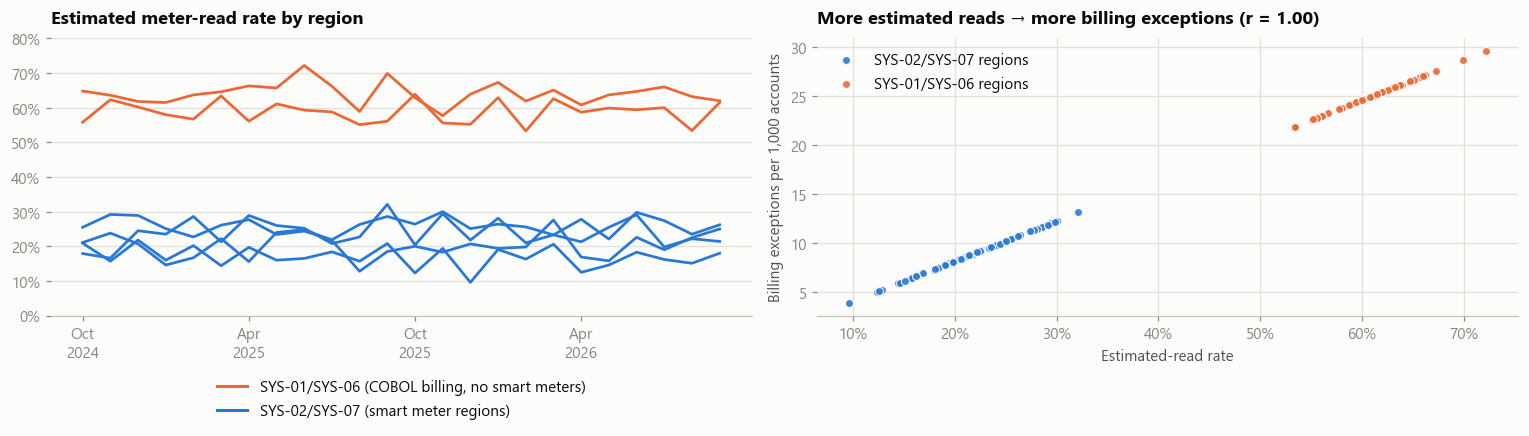

In [32]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.2))
mmonths = sorted(mr.month.unique())
for region, g in mr.groupby("region"):
    legacy = stack[region].startswith("SYS-01")
    a1.plot(np.arange(len(g)), g.estimated_read_rate.values, color=ORANGE if legacy else BLUE, lw=1.8)
a1.plot([], [], color=ORANGE, label="SYS-01/SYS-06 (COBOL billing, no smart meters)")
a1.plot([], [], color=BLUE, label="SYS-02/SYS-07 (smart meter regions)")
a1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1)
month_ticks(a1, mmonths, every=6); pct_axis(a1); a1.set_ylim(0, 0.8)
a1.set_title("Estimated meter-read rate by region")

for legacy, g in mr.groupby(mr.systems_serving_region.str.startswith("SYS-01")):
    a2.scatter(g.estimated_read_rate, g.exceptions_per_1k, s=28, color=ORANGE if legacy else BLUE,
               edgecolor=SURFACE, linewidth=0.8, alpha=0.9,
               label="SYS-01/SYS-06 regions" if legacy else "SYS-02/SYS-07 regions")
a2.legend(loc="upper left")
a2.grid(axis="x", visible=True); pct_axis(a2, "x")
a2.set_xlabel("Estimated-read rate"); a2.set_ylabel("Billing exceptions per 1,000 accounts")
a2.set_title(f"More estimated reads → more billing exceptions (r = {r:.2f})")
plt.tight_layout(); plt.show()

### 6.4 Systems & unit-cost context (B, F)

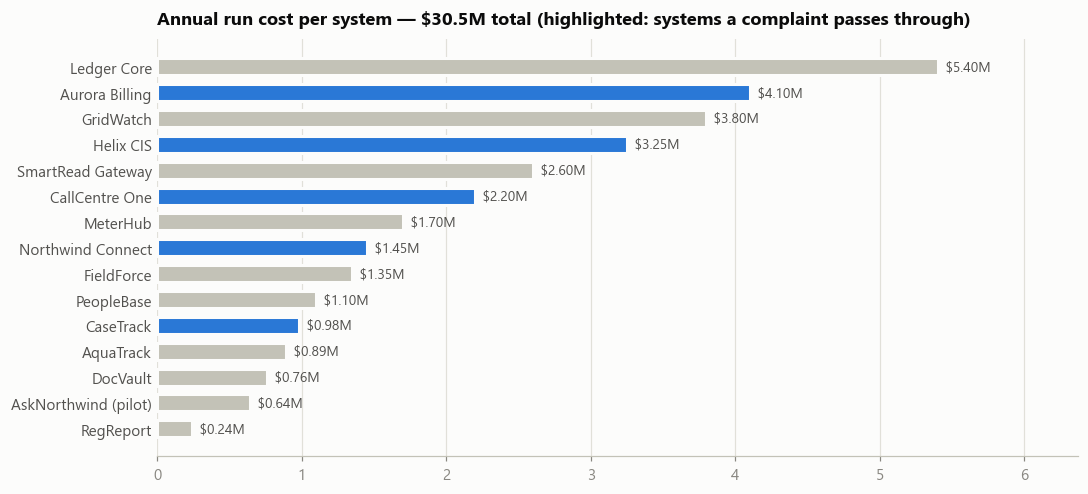

Complaint-path systems cost $11,980,000/yr
Complaint handling cost over two years: 16,546 × $68 + 8,870 × $121 ≈ $2,198,398
Calderfield: 32 vacancies × $46,000 = $1,472,000/yr of unfilled agent capacity
Compensation payments issued: 764 × $40 = $30,560


In [33]:
fig, ax = plt.subplots(figsize=(10, 4.6))
s = systems.set_index("system_name").annual_run_cost.sort_values(ascending=False)
hbar(ax, s.index, s.values / 1e6, emphasis=lambda l: l in {"Aurora Billing", "Helix CIS", "CaseTrack", "Northwind Connect", "CallCentre One"},
     fmt="${:.2f}M")
ax.set_title(rf"Annual run cost per system — \${systems.annual_run_cost.sum() / 1e6:.1f}M total "
             "(highlighted: systems a complaint passes through)")
plt.tight_layout(); plt.show()

complaint_stack = systems[systems.system_id.isin(["SYS-01", "SYS-02", "SYS-03", "SYS-04", "SYS-05"])]
print(f"Complaint-path systems cost ${complaint_stack.annual_run_cost.sum():,.0f}/yr")
print(f"Complaint handling cost over two years: {n_one:,} × $68 + {n_tr:,} × $121 ≈ "
      f"${n_one * cost_avg + n_tr * cost_tr:,.0f}")
print(f"Calderfield: 32 vacancies × ${uc['Contact centre agent, fully loaded']:,.0f} = "
      f"${32 * uc['Contact centre agent, fully loaded']:,.0f}/yr of unfilled agent capacity")
missed_comp = (complaints.resolution_action == "Compensation payment issued").sum()
print(f"Compensation payments issued: {missed_comp:,} × $40 = ${missed_comp * uc['Compensation payment, missed appointment or outage']:,.0f}")

### 6.5 Customer bill-breakdown demo figures (`BillBreakdown.tsx`)
The bill breakdown uses **demo numbers**, not challenge data (the Impact slide lists "real billing data instead of demo
numbers" as a next step). Quick arithmetic check of the hard-coded values:

In [34]:
bill = {"Electricity usage": 82.40, "Water usage": 34.70, "Service/delivery charges": 21.30, "Taxes": 13.85}
bill_total = round(sum(bill.values()), 2)
print(f"Sum of line items: ${bill_total:.2f} | 'Amount Due' shown: $152.30 | difference: ${152.30 - bill_total:.2f}")
claim("BillBreakdown.tsx (demo data)", "Line items add up to Amount Due", f"${bill_total:.2f}", "$152.30", bill_total == 152.30,
      note="Demo values: line items sum to $152.25, $0.05 short of the amount due shown")

Sum of line items: $152.25 | 'Amount Due' shown: $152.30 | difference: $0.05


'$152.25'

## 7. Verification table — every number in the project

In [35]:
audit = pd.DataFrame(CLAIMS)
display(audit.style.hide(axis="index").set_properties(**{"text-align": "left"}))
print(f"{(audit.verified == '✅').sum()} of {len(audit)} claims verified against the CSVs.")
flagged = audit[audit.verified != "✅"]
if len(flagged):
    display(Markdown("**Needs attention:**"))
    display(flagged)

where,statement,computed,shown in project,verified,note
Landing page / Problem slide,Customers served,1.8M,1.8M,✅,
Problem slide footer,Complaints in the data set,"25,416","25,416",✅,
Problem slide footer,Date range,Oct 2024 – Sep 2026,Oct 2024 – Sep 2026,✅,
Problem slide title,"Avg days to close, Sep 2026",38.2 days,38 days,✅,
Problem slide,Days to close vs Oct 2024,4.20×,4×,✅,
ProblemCharts DaysToCloseChart,Chart start / end labels,9 → 38 days,9 days → 38 days,✅,
Problem slide / TransferChart,Share transferred between systems,34.9%,35% (34.9),✅,
TransferChart,Transferred complaints,"8,870","8,870",✅,
TransferChart,One-system complaints,"16,546","16,546",✅,
TransferChart,"Reopen rate, transferred (of closed)",29.2%,29%,✅,


34 of 35 claims verified against the CSVs.


**Needs attention:**

,where,statement,computed,shown in project,verified,note
34,BillBreakdown.tsx (demo data),Line items add up to Amount Due,$152.25,$152.30,⚠️,"Demo values: line items sum to $152.25, $0.05 ..."


### Notes & caveats
- **“4× longer”** compares Sep 2026 (38.2 days) with Oct 2024 (9.1 days). Oct 2024 is the first month of data, so it only
  contains fast closures; from Nov 2024 (16.5 days) the rise is 2.3×. Both numbers are in the KPI file as reported.
- **“3× as often”** uses reopen rates among *closed* complaints (29.2 % vs 8.9 % = 3.3×); on all complaints it is 26.9 % vs 8.4 % (3.2×).
- **“23 % information-only”** is 5,865 of all 25,416 complaints; as a share of *closed* complaints it is 24.6 %.
- **“77 % SLA breached”** includes open complaints already past their SLA; on closed complaints alone it is 75.4 %.
- **“~$235K”** takes the $68 blended average as the non-transferred cost, so it is a conservative estimate; using the implied
  one-system cost instead gives a larger figure (see 4.1).
- Staffing figures are the **latest month (Sep 2026)**, matching the dashboard's default view.